In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from networkx.classes import edges

from glue_sessions.glue_sessions import *
from licks import *

In [178]:
# Magics
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [179]:
# Plotting style
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('notebook')

# Load behavioral data

In [180]:
experiments = [
    '2AFC_2',
    '2AFC_3'#,
    # '2AFC_4',
    # '2AFC_5',
    # '2AFC_6',
]
df_behavior = glue_groups(experiments)

# Filter data

In [181]:
# Filters for groups 1-3
# df_behavior = df_behavior[df_behavior.Stage == 4].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Motor == 4].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Filters for groups 4-5 (otherwise bump in lick rate before stimulus onset)
# df_behavior = df_behavior[df_behavior.Task == 'FD'].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Delay == 0.5].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Filter for groups 1-4 (otherwise bump in lick rate before stimulus onset)
df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)
print(f'{round(len(df_behavior) / 1000)}k trials')

219k trials


# Add lick data

In [182]:
# Save old columns for comparison later
old_columns = list(df_behavior.columns)

# Add lick data to the DataFrame
df_behavior = add_lick_data(df_behavior)

# Print new columns added to the DataFrame
new_columns = list(df_behavior.columns)
new_columns = [col for col in new_columns if col not in old_columns]
print(new_columns)

0.16% of premature lick trials (before response window)
Port1In or Port2In are already lists
['LicksLeft', 'LicksRight', 'nLicksLeft', 'nLicksRight', 'ILI_Left', 'ILI_Right', 'RT', 'RT2']


In [183]:
# There is something wrong with the RTs in 2AFC_4 experiment, that they are shifted by ca. 150 ms. I think it is due to the dramatic redesign of the finite state machine (FSM) that we did from that group onwards. The 150 ms matches the time the motor needs to travel, so it is likely related to that. Need to check further. For now, we will shift the RTs back by 150 ms to match the other experiments.
if '2AFC_4' in experiments:
    df_behavior.loc[df_behavior.Experiment == '2AFC_4', 'RT'] -= 0.15

# Plot RTs distributions

## All trials

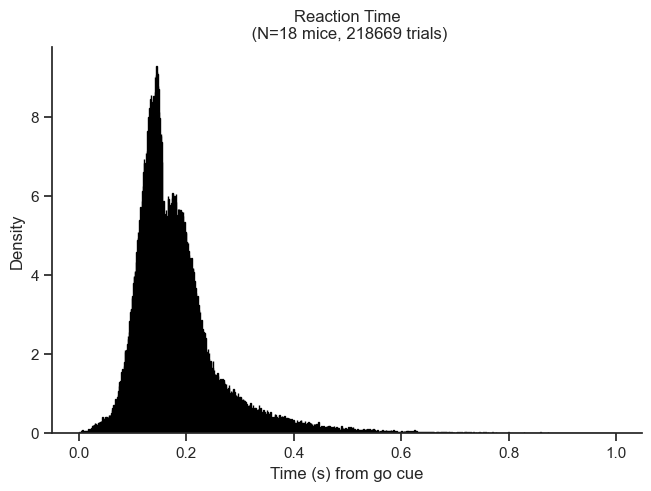

In [184]:
plot_rts(df_behavior, density=True)

This is the rawest representation of RT data. There is a bimodal distribution of RTs across all mice. The overall distribution has a shoulder-like second peak (lower) after the first one. It is likely due to the presence of two different strategies in the task: one that involves a fast response and another that involves a slower response. Let's rule out other hypotheses first (easier and faster to check).

One hypothesis is that the difference evidence levels (ILDs) drives different RTs. To examine this, we can plot a RT distribution per ILD level. To visually compare the distributions, a Kernel Desnity Estimation (KDE) plot is preferred.

## Gaussian Mixture fit

Component 0: mean=0.13 s, std=0.03 s, weight=0.53
Component 1: mean=0.20 s, std=0.03 s, weight=0.33
Component 2: mean=0.30 s, std=0.06 s, weight=0.11
Component 3: mean=0.47 s, std=0.15 s, weight=0.03


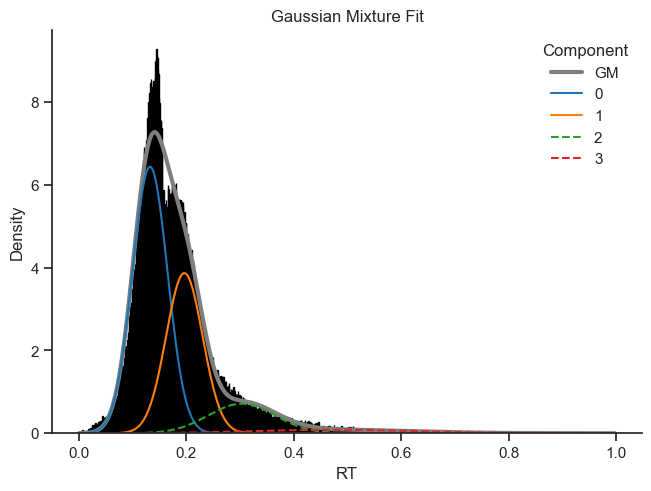

In [210]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# Get your data as a 1D array (drop NaNs if needed)
rt = df_behavior['RT'].dropna().values.reshape(-1, 1)
# rt = df_behavior['RT'].dropna().clip(upper=0.4).values.reshape(-1, 1)

# Manual initialization of RTs near where the two peaks are expected
# means_init = np.array([[0.15], [0.2]])

# Fit a 2-component Gaussian mixture
gm = GaussianMixture(n_components=4)
gm.fit(rt)

# Plot the RT distribution
plot_rts(df_behavior, density=True)

# Plot the GMM fit (both components and the overall mixture)
x = np.linspace(rt.min(), rt.max(), 1000).reshape(-1, 1)
logprob = gm.score_samples(x)
pdf = np.exp(logprob)
plt.plot(x, pdf, color='tab:gray', lw=3, label='GM')

# Get predicted component for each sample
labels = gm.predict(rt)

# Flatten means and covariances
gm_means = gm.means_.flatten()
gm_covariances = gm.covariances_.flatten()
gm_weights = gm.weights_.flatten()

# Sort component indices by mean RT
sorted_idx = np.argsort(gm_means)

# Create a mapping from old component label -> new label by order of means
label_map = {old_label: new_label for new_label, old_label in enumerate(sorted_idx)}

# Relabel the predicted labels accordingly
sorted_labels = np.array([label_map[l] for l in labels])

# Plot the components in order with new labels
for i in range(len(sorted_idx)):
    orig_label = sorted_idx[i]
    mean = gm_means[orig_label]
    std = np.sqrt(gm_covariances[orig_label])
    weight = gm_weights[orig_label]
    # sns.kdeplot(rt[sorted_labels == i].squeeze(), ls=ls, label=i)
    component_pdf = weight * norm.pdf(x, loc=mean, scale=std)
    ls = '--' if i in [2, 3] else '-'
    plt.plot(x, component_pdf, ls=ls, label=i)
    print(f'Component {i}: mean={mean:.2f} s, std={std:.2f} s, weight={weight:.2f}')

plt.xlabel('RT')
plt.ylabel('Density')
plt.title('Gaussian Mixture Fit')
plt.legend(frameon=False, title='Component')
sns.despine()

In [211]:
print(sorted(gm_means))

[0.13211315471876445, 0.19609558192306176, 0.30294221500312735, 0.47319481562434756]


## By ILD

ILD 0: peak RT = 0.141 s
ILD 2: peak RT = 0.143 s
ILD 4: peak RT = 0.143 s
ILD 8: peak RT = 0.143 s
ILD 70: peak RT = 0.139 s


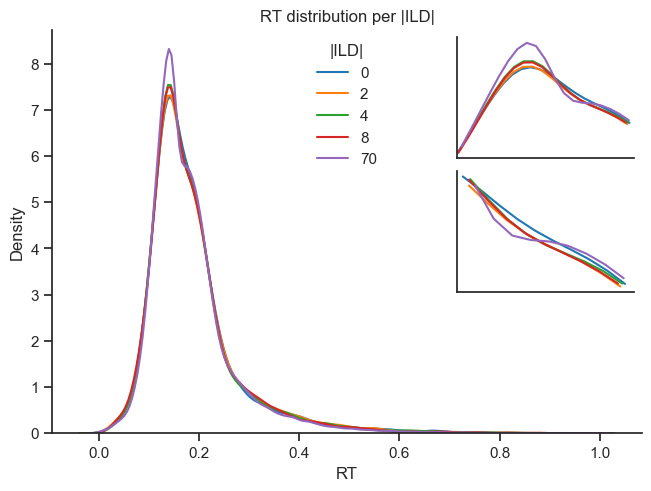

In [223]:
plt.figure(constrained_layout=True)

# Collapse the signed ILD levels to absolute values for cleaner visualization
df_behavior['absILD'] = df_behavior['ILD'].abs()
abs_ilds = sorted(df_behavior.absILD.unique().astype(int))

peak_rts = {}
# Plot the RT distribution for each absolute ILD level
for ild in abs_ilds:
    df_ild = df_behavior[df_behavior.absILD == ild]

    # Plot and capture the Line2D object
    line = sns.kdeplot(df_ild.RT, label=ild)

    # Extract x and y data from the plotted line
    line = plt.gca().lines[-1]
    x, y = line.get_data()

    # Find the peak RT (x at maximum y)
    peak_rt = x[np.argmax(y)]
    peak_rts[ild] = peak_rt

# Optional: print peaks
for ild, peak in peak_rts.items():
    print(f'ILD {ild}: peak RT = {peak:.3f} s')

plt.title('RT distribution per |ILD|')
plt.xlabel('RT')
plt.ylabel('Density')
plt.legend(loc='upper center', frameon=False, title='|ILD|')
sns.despine()

# Zoomed inset on the peak of the distribution
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper right')
xlim = (0.1, 0.2)

for line in ax.lines:
    x = line.get_xdata()
    y = line.get_ydata()
    mask = (x >= xlim[0]) & (x <= xlim[1])
    ax_inset.plot(x[mask], y[mask], label=line.get_label())

ax_inset.set_xlim(xlim)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
sns.despine(ax=ax_inset)

# Zoomed inset on the second peak of the distribution
ax_inset = inset_axes(ax, width="30%", height="30%", loc='center right')
xlim = (0.15, 0.2)

for line in ax.lines:
    x = line.get_xdata()
    y = line.get_ydata()
    mask = (x >= xlim[0]) & (x <= xlim[1])
    ax_inset.plot(x[mask], y[mask], label=line.get_label())

ax_inset.set_xlim(xlim)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
sns.despine(ax=ax_inset)

The ILD does not seem to explain the existence bimodality in the RT distribution, as the bimodality is present across all ILD levels.

Nevertheless, zooming in the peak of the distribution (0.1-0.2 s), we can see that the RTs are faster for lower ILD levels, which is expected as the evidence is more certain. What is surprising is this modulation to show up despite the fact that mice were head-fixed. In addition, zoomin in the second peak of the distribution (0.15-0.2 s), we can see that the second peak is more pronounced for lower ILD levels, suggesting that the bimodality is actually modulated by ILD level.

Too many lines can make on top of each other make it hard to disentangle the ILD impact on RT, so we can plot the RT distribution for each ILD level separately.

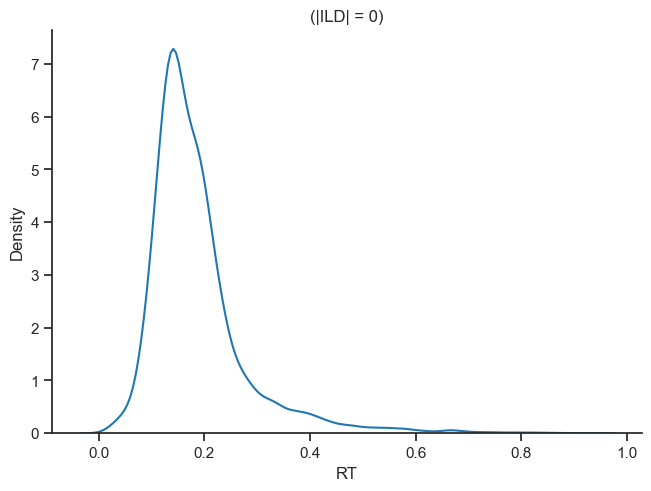

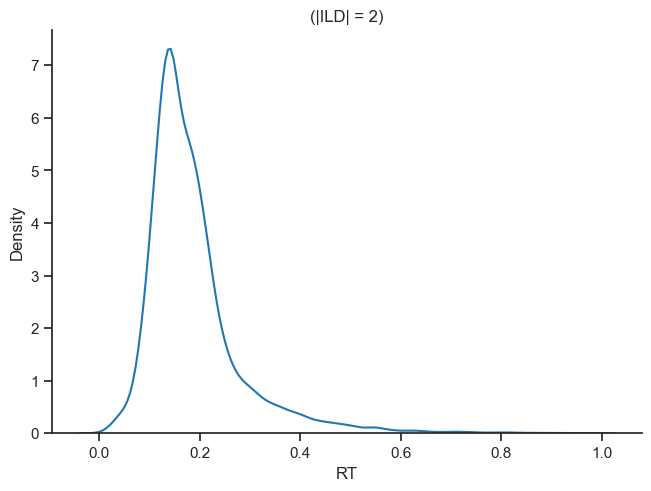

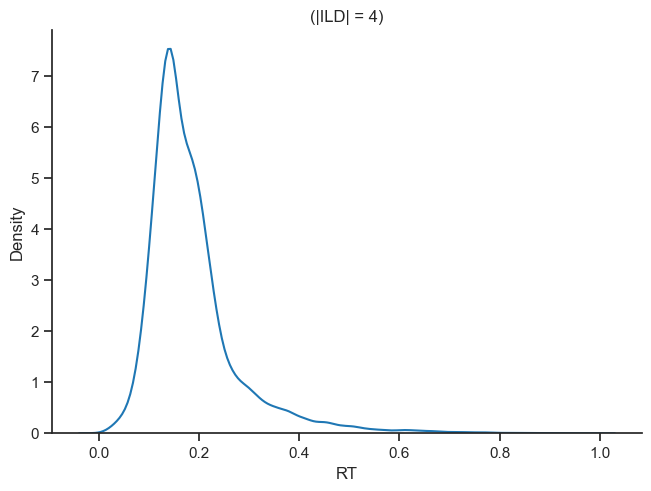

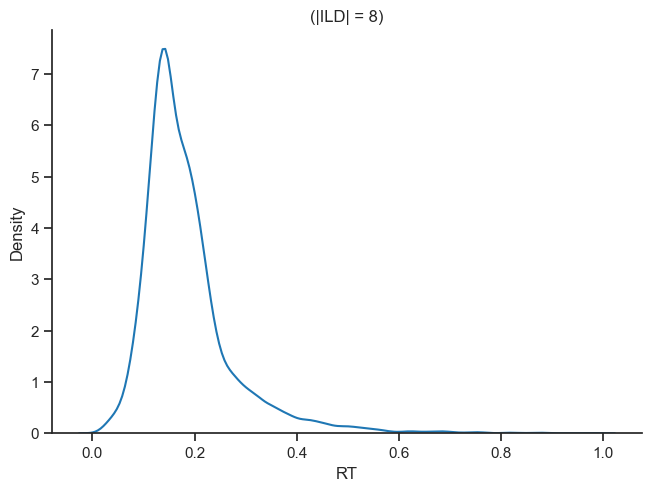

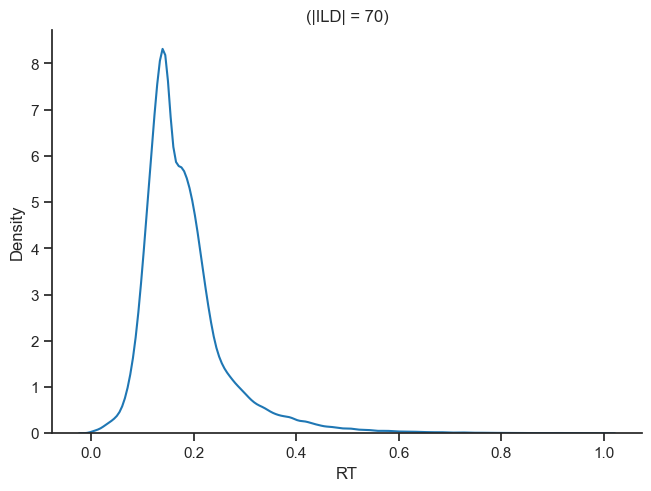

In [187]:
# Collapse the signed ILD levels to absolute values for cleaner visualization
df_behavior['absILD'] = df_behavior['ILD'].abs()
abs_ilds = sorted(df_behavior.absILD.unique().astype(int))

# Plot the RT distribution for each absolute ILD level
for ild in abs_ilds:
    plt.figure(constrained_layout=True)
    df_ild = df_behavior[df_behavior.absILD == ild]
    sns.kdeplot(df_ild.RT, label=ild)
    plt.title(f'(|ILD| = {ild})')
    sns.despine()

This is interesting. Although the bimodality is present in all ILD levels, the second peak is more pronounced for lower ILD levels. This suggests that the bimodality is not driven by differences in evidence levels, but rather by a different strategy used by the mice.

Another hypothesis is that the bimodality is driven by differences in behavioral variables such as outcome, choice, stimulus, repeat, or previous outcome. To examine this, we can plot a RT distribution per behavioral variable split in 2 conditions.

## Splits

### Outcome

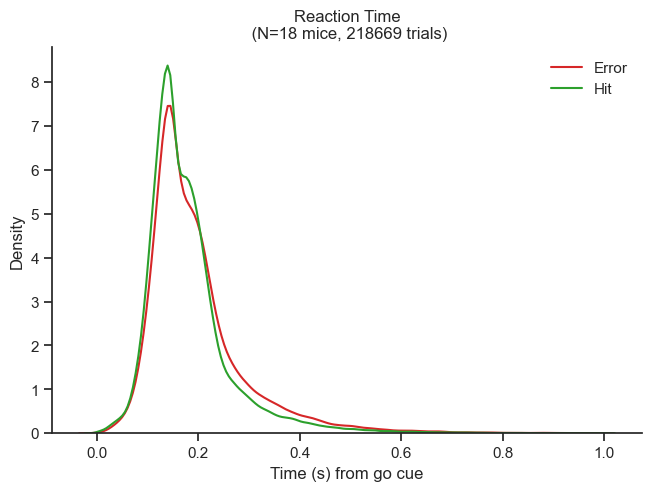

In [188]:
plot_rts_split(df_behavior, split='outcome', kind='kde')

### Choice

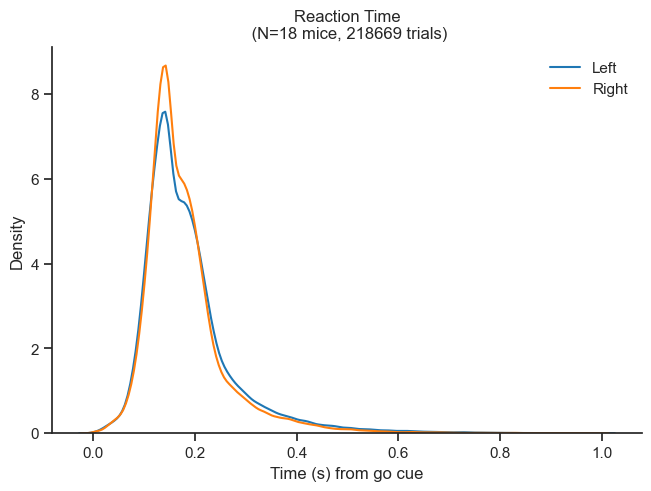

In [189]:
plot_rts_split(df_behavior, split='choice', kind='kde')

### Stimulus

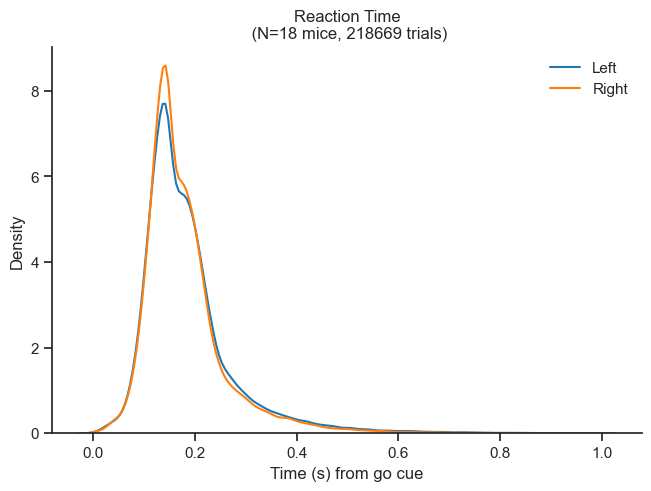

In [190]:
plot_rts_split(df_behavior, split='stim', kind='kde')

### Repeat

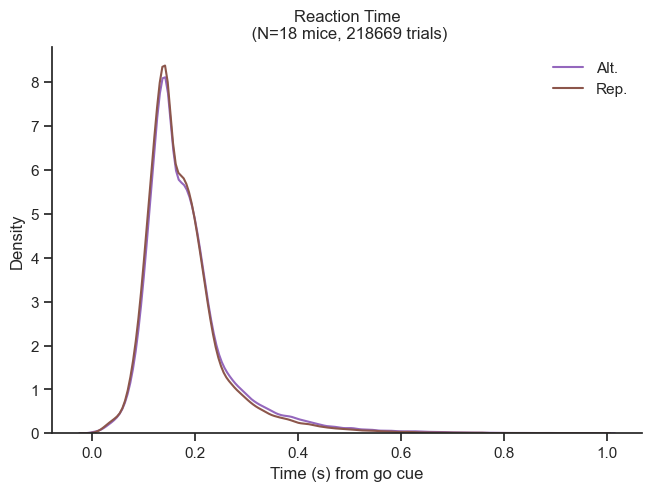

In [191]:
plot_rts_split(df_behavior, split='repeat', kind='kde')

### Previous outcome

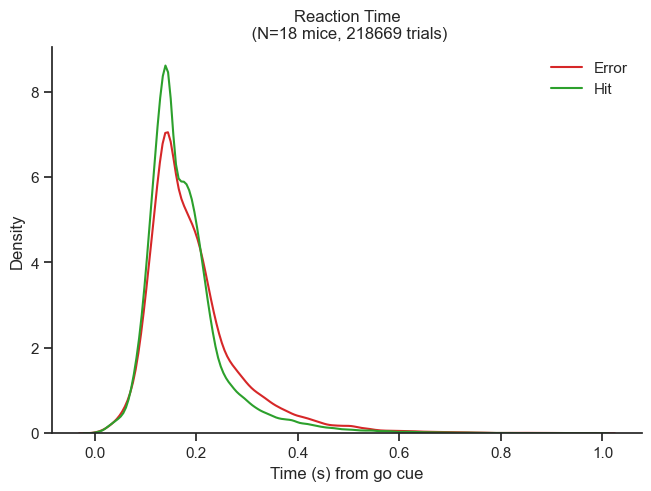

In [192]:
plot_rts_split(df_behavior, split='prev_out', kind='kde')

This bimodality can not be explained by differences in behavioral variables such as outcome, choice, stimulus, repeat, or previous outcome.

## 1st vs 2nd half of the session

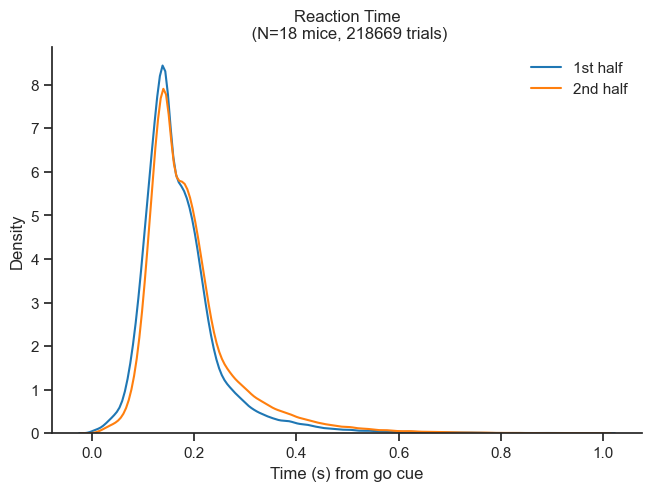

In [193]:
# Plot the RT distribution for the first and second half of the session
df_behavior['SessionHalf'] = (df_behavior.Trial >= df_behavior.groupby('Session').Trial.transform('max') / 2).astype(int)
plot_rts_split(df_behavior, split='session_half', kind='kde')

The bimodality is present in both halves of the session, suggesting that it is not driven by a change in the internal state of the animal. The RT distribution is similar in both halves of the session, with a slight shift towards slower RTs in the second half.

Another possibility is that the bimodality just results from the individual variability in the RTs of each subject. To examine this, we can plot the RT distribution for each subject separately. If the bimodality is driven by individual variability, we would expect to see a unimodal distribution in each subject.

## Check the bimodality is present in every subject

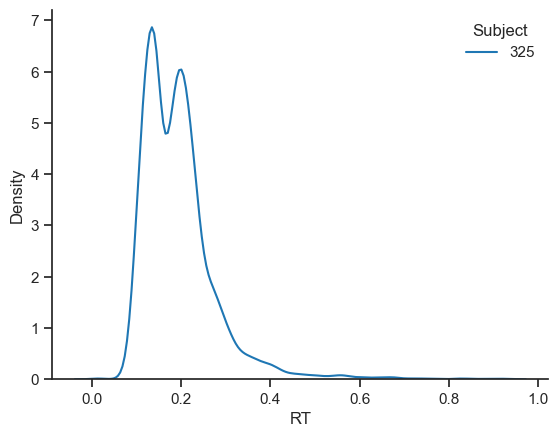

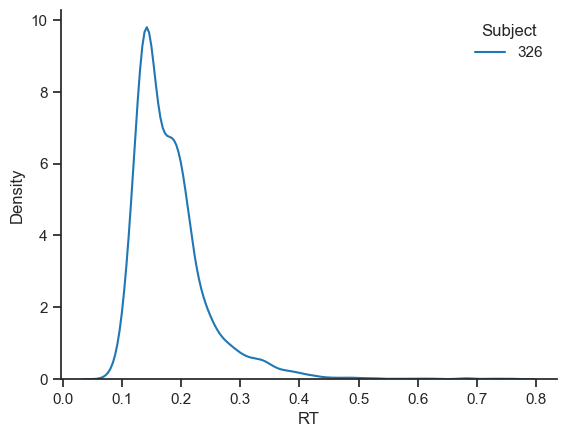

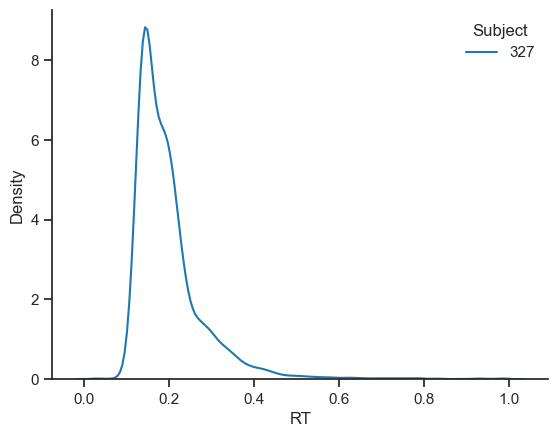

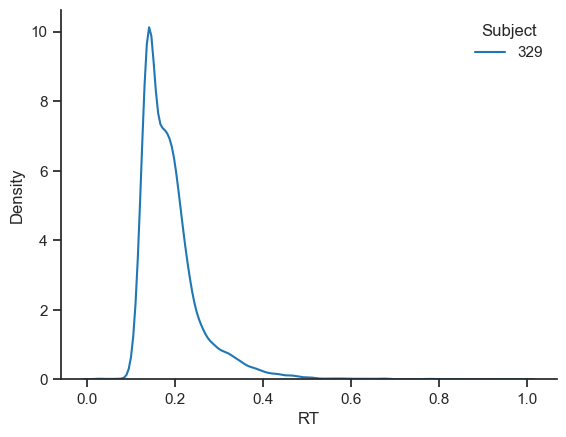

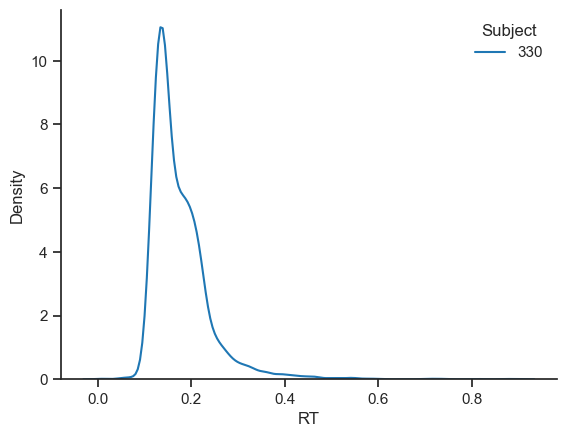

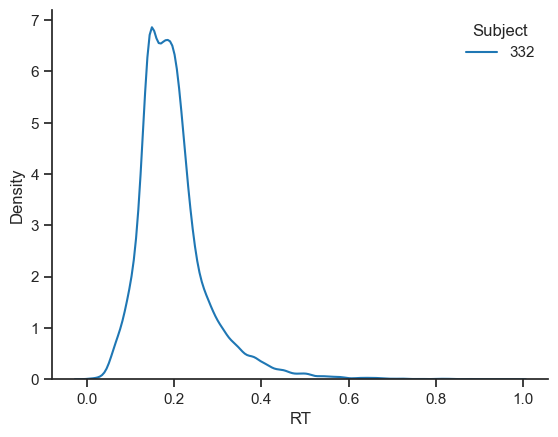

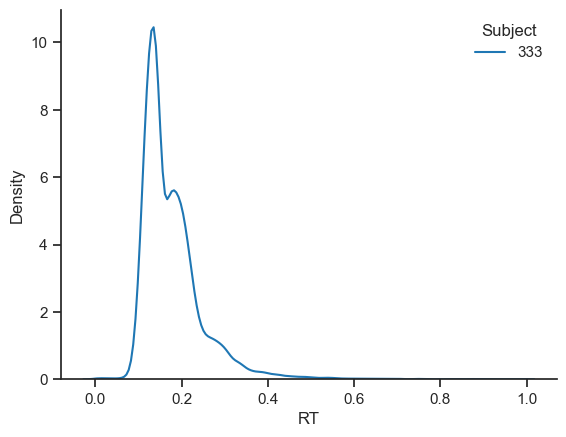

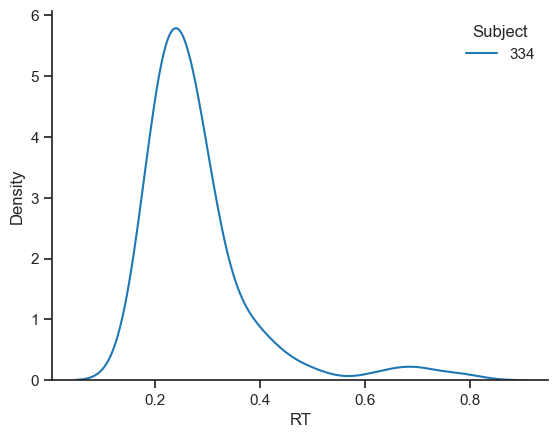

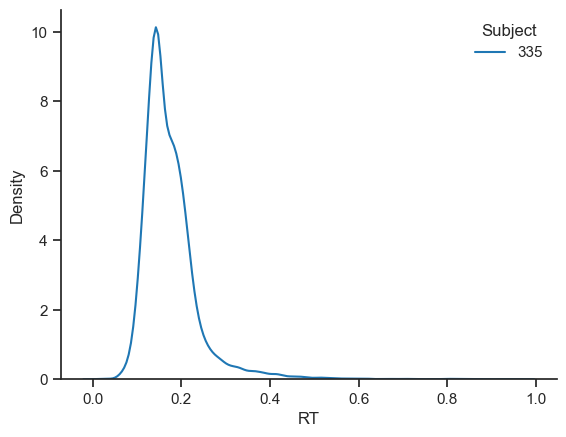

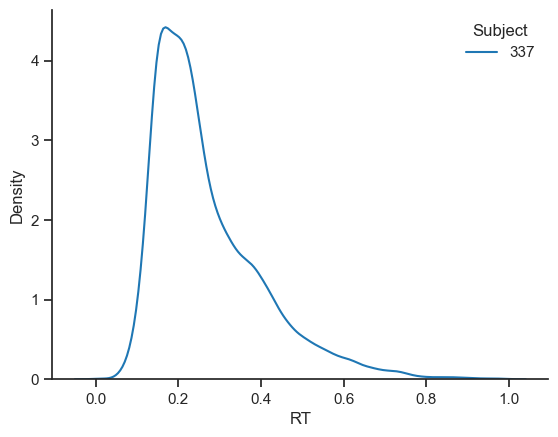

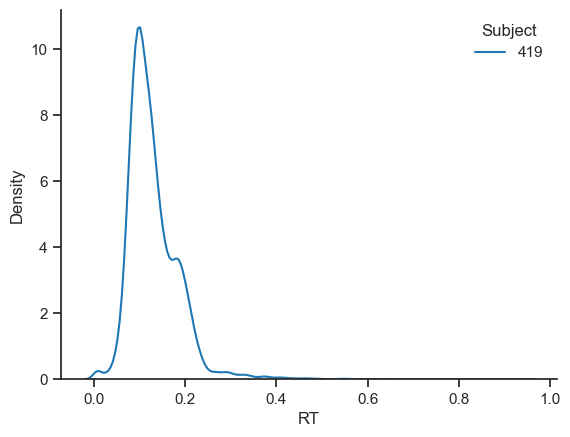

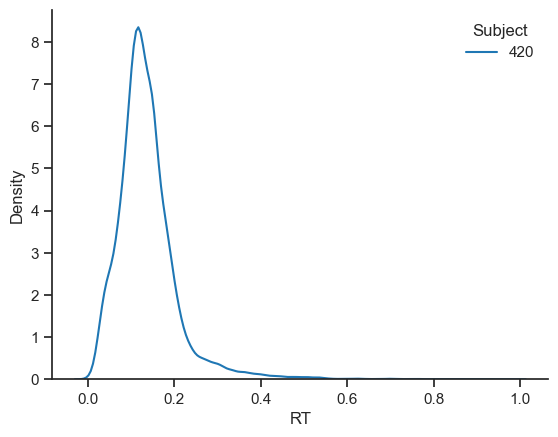

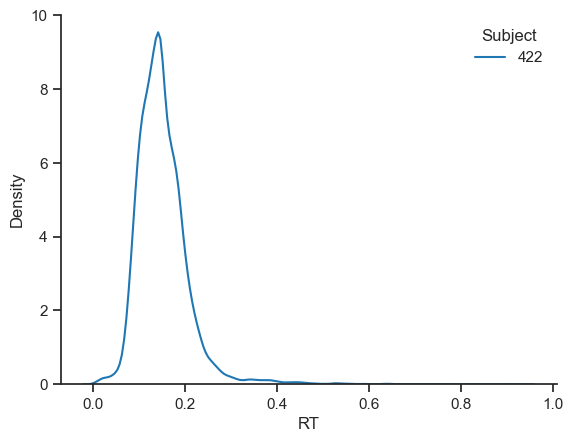

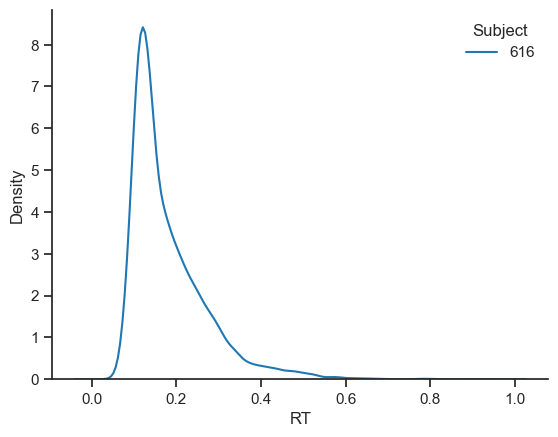

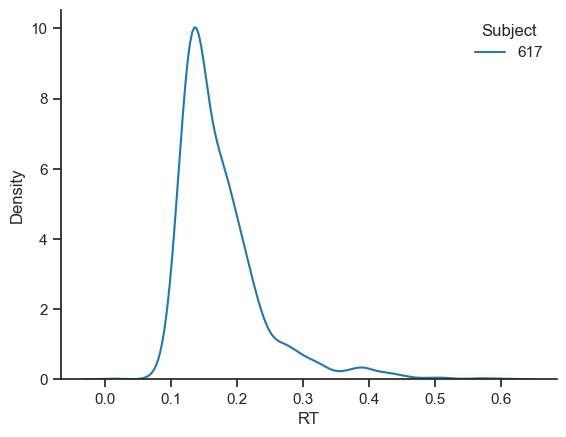

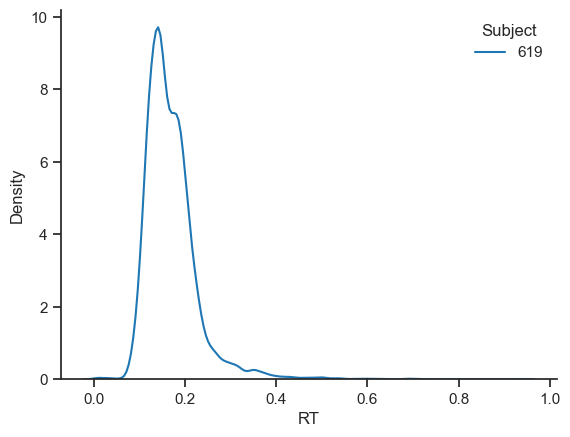

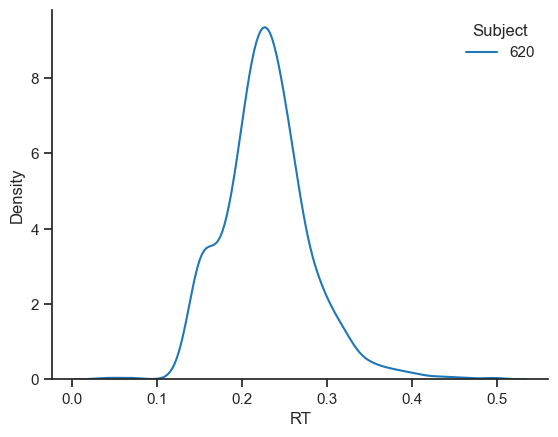

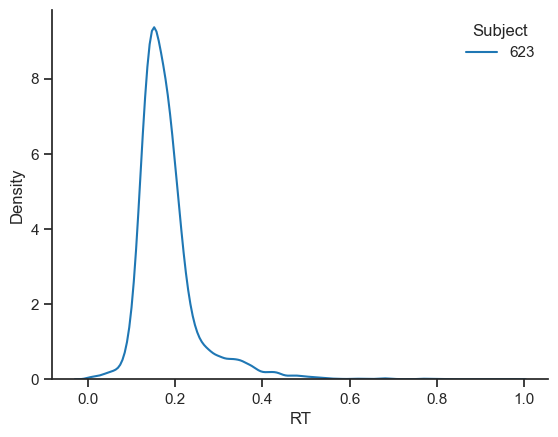

In [194]:
# Check the bimodality is present in every subject
for i in range(len(df_behavior.Subject.unique())):
    subject = df_behavior.Subject.unique()[i]
    df_subject = df_behavior[df_behavior.Subject == subject]
    plt.figure()
    sns.kdeplot(df_subject.RT, label=subject)
    plt.xlabel('RT')
    plt.ylabel('Density')
    plt.legend(loc='upper right', frameon=False, title='Subject')
    sns.despine()

## Hidden Markov Model (HMM)

Another possibility is that the bimodality reflects the a change in the internal state of the animal (e.g. motivation, reduced by satiation as time passes) that is not captured by the behavioral variables. To examine this, we can split the data of each session into first and second half and plot the RT distribution for each half. If the bimodality is driven by a change in the internal state of the animal, we would expect to see a difference in the RT distribution between the first and second half of the session.

# Plot Chronometric Curves

## All trials

   absILD        RT
0     0.0  0.186289
1     2.0  0.187186
2     4.0  0.185685
3     8.0  0.184547
4    70.0  0.182010


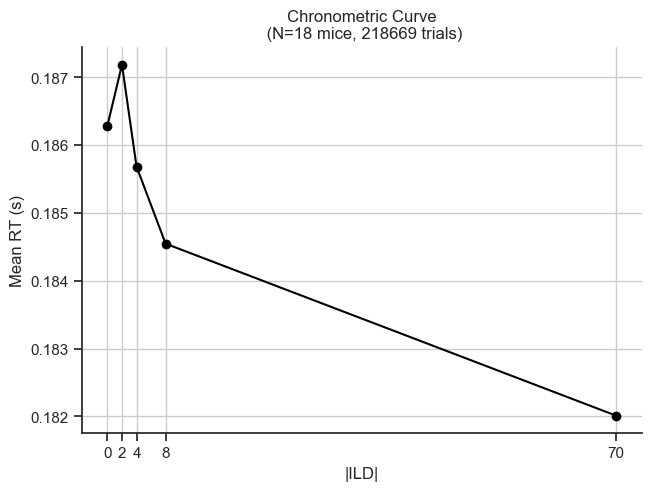

In [195]:
plot_chrono_curve(df_behavior, absolute=True)

## Splits

### Outcome

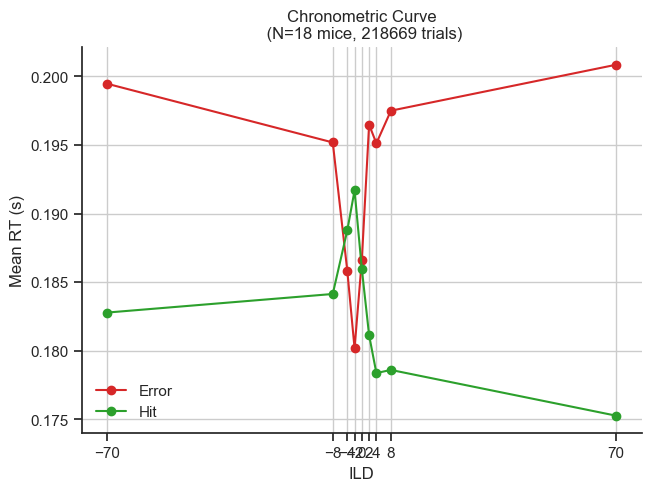

In [196]:
plot_chrono_curve_split(df_behavior, split='outcome', absolute=False)

### Choice

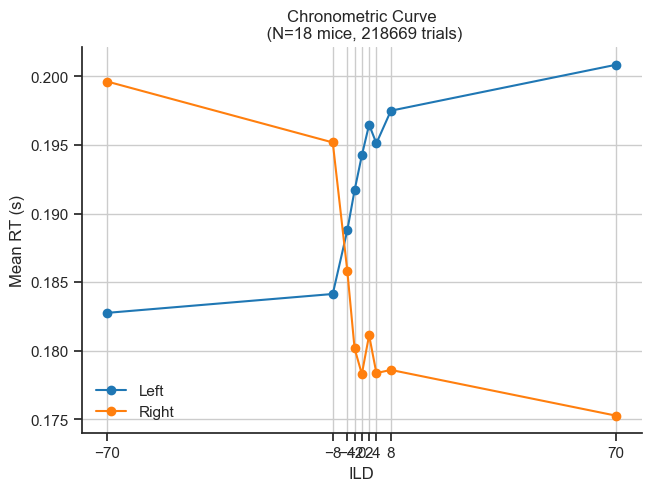

In [197]:
plot_chrono_curve_split(df_behavior, split='choice', absolute=False)

### Stimulus

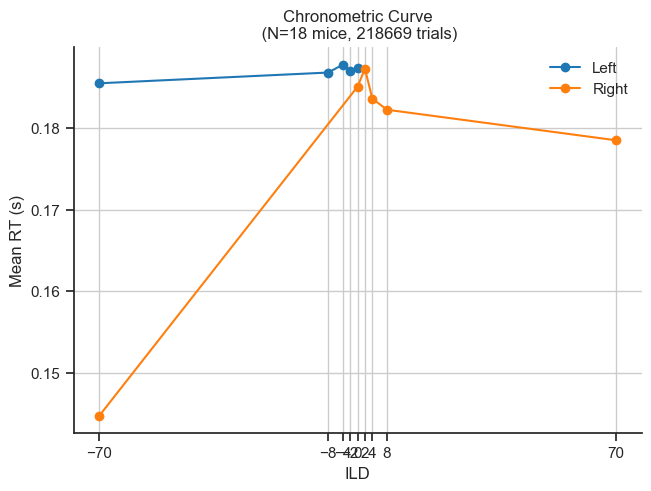

In [198]:
plot_chrono_curve_split(df_behavior, split='stim', absolute=False)

### Repeat

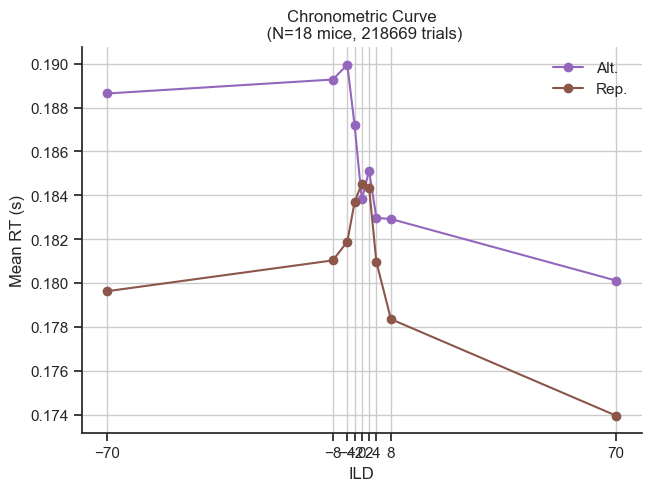

In [199]:
plot_chrono_curve_split(df_behavior, split='repeat', absolute=False)

### Previous outcome

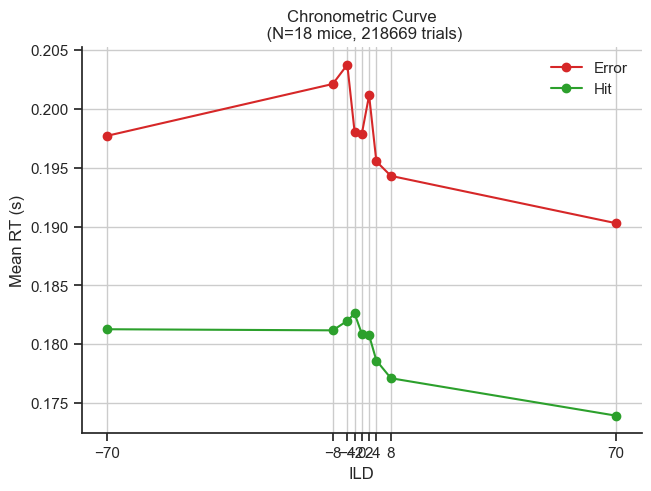

In [200]:
plot_chrono_curve_split(df_behavior, split='prev_out', absolute=False)

In [201]:
# # Plot licks PSTH
# bins, left_psth = compute_psth(licks_left, time_win=[-1, 3], bin_size=0.1)
# bins, right_psth = compute_psth(licks_right, time_win=[-1, 3], bin_size=0.1)
# bins = bins[:-1]  # Remove the last bin edge to match the histogram length
# plot_licks_psth(bins, licks_left, licks_right)